# 🧠 Support Vector Machine (SVM) –

## 📌 ¿Qué es un SVM?
El **Support Vector Machine (SVM)** es un modelo de aprendizaje supervisado utilizado principalmente para **clasificación**.  
Su objetivo es encontrar el **mejor hiperplano** que separe las clases con el **máximo margen**.

---

## 📌 Hiperplano y Margen Máximo
Un **hiperplano** es una línea o plano que divide los datos en clases.

El SVM busca:
- Un hiperplano que **separe correctamente las clases**.
- Que el **margen sea lo más grande posible**.

Los puntos más cercanos al hiperplano se llaman **vectores de soporte**, y son los que definen la frontera.




## 📌 Ventajas del SVM
- Funciona muy bien con datos complejos.
- Es robusto al sobreajuste.
- Excelente rendimiento con datos de alta dimensión.
- Requiere pocos datos para ser efectivo.

---

## 📌 Desventajas del SVM
- Entrenamiento lento con datasets grandes.
- Difícil de ajustar (C, gamma, kernel).
- Poco interpretable comparado con modelos basados en árboles.

---

## 📌 Cuándo usar SVM
- Cuando el dataset es **pequeño o mediano**.
- Cuando las clases no son linealmente separables.
- Cuando los datos tienen **alta dimensionalidad**.
- Para problemas de **clasificación binaria compleja**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic').dropna()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [3]:
cols = ['pclass','sex','age','sibsp','parch','fare','embarked']
target = 'survived'
X = df[cols]
y = df[target]

In [4]:
X = pd.get_dummies(X,columns=['sex','embarked'],drop_first=True)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# APLICAMOS EL ALGORITMO DE SVC

In [8]:
svc_model = SVC()

In [9]:
svc_model.fit(X_train,y_train)

SVC()

In [10]:
from sklearn.metrics import accuracy_score

y_pred = svc_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Precisión del modelo: {accuracy}')

Precisión del modelo: 0.6486486486486487


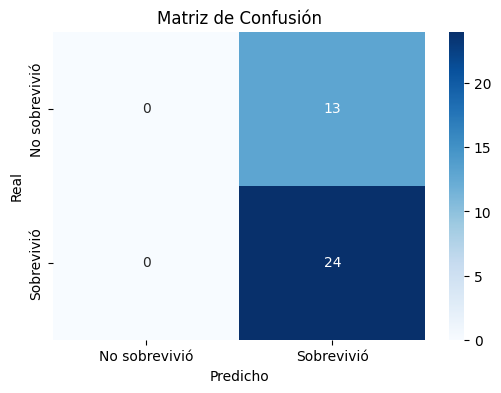

In [11]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()